<a href="https://colab.research.google.com/github/shambhavidpsg-beep/Shambhavi4C2K24CSUN01200/blob/main/KNN_execution_on_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

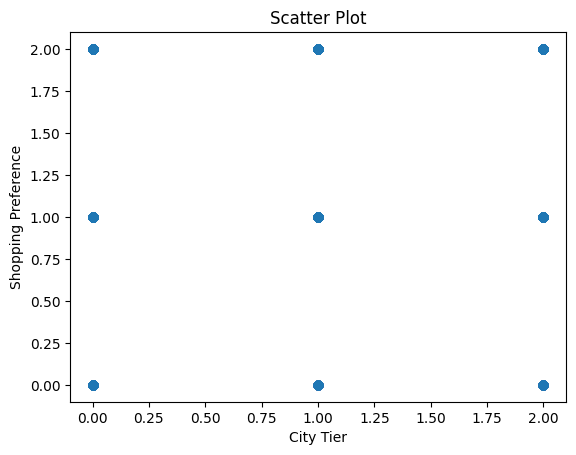

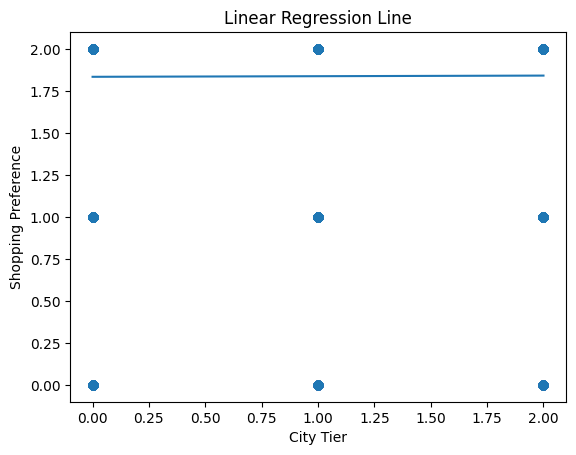

Slope: 0.0036114774014740845
Intercept: 1.8340438944497643


In [1]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Step 2: Load dataset
data = pd.read_csv("Consumer_Shopping_Trends_2026 (6).csv")

# Step 3: Select required columns
data = data[['city_tier', 'shopping_preference']]

# Step 4: Handle missing values
data = data.dropna()

# Step 5: Convert categorical data to numeric (if needed)
le1 = LabelEncoder()
le2 = LabelEncoder()

data['city_tier'] = le1.fit_transform(data['city_tier'])
data['shopping_preference'] = le2.fit_transform(data['shopping_preference'])

# Step 6: Define X and y
X = data[['city_tier']]   # independent variable
y = data['shopping_preference']  # dependent variable

# Step 7: Apply Linear Regression
model = LinearRegression()
model.fit(X, y)

# Step 8: Predictions
y_pred = model.predict(X)

# Step 9: Scatter plot
plt.scatter(X, y)
plt.xlabel("City Tier")
plt.ylabel("Shopping Preference")
plt.title("Scatter Plot")
plt.show()

# Step 10: Regression line plot
plt.scatter(X, y)
plt.plot(X, y_pred)   # regression line
plt.xlabel("City Tier")
plt.ylabel("Shopping Preference")
plt.title("Linear Regression Line")
plt.show()

# Step 11: Print equation
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

In [2]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load dataset
data = pd.read_csv("Consumer_Shopping_Trends_2026 (6).csv")

# Step 3: Select required columns
data = data[['city_tier', 'shopping_preference']]

# Step 4: Handle missing values
data = data.dropna()

# Step 5: Encode categorical data
le1 = LabelEncoder()
le2 = LabelEncoder()

data['city_tier'] = le1.fit_transform(data['city_tier'])
data['shopping_preference'] = le2.fit_transform(data['shopping_preference'])

# Step 6: Define X and y
X = data[['city_tier']]
y = data['shopping_preference']

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 8: Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 9: Apply KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 10: Predictions
y_pred = knn.predict(X_test)

# Step 11: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8744698897370653
Confusion Matrix:
 [[   0    0   72]
 [   0    0  224]
 [   0    0 2062]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.00      0.00      0.00       224
           2       0.87      1.00      0.93      2062

    accuracy                           0.87      2358
   macro avg       0.29      0.33      0.31      2358
weighted avg       0.76      0.87      0.82      2358



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


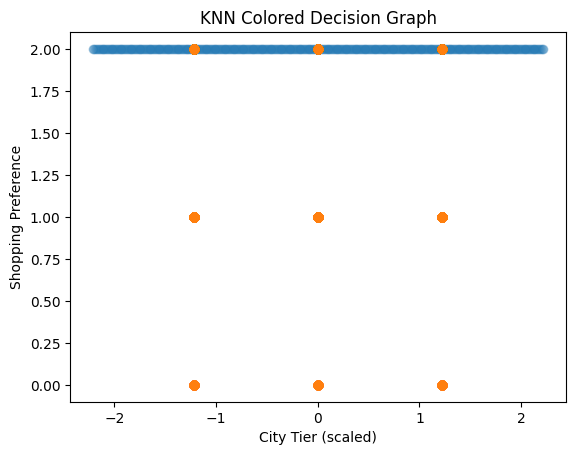

In [3]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Step 2: Load dataset
data = pd.read_csv("Consumer_Shopping_Trends_2026 (6).csv")

# Step 3: Select columns
data = data[['city_tier', 'shopping_preference']].dropna()

# Step 4: Encode categorical data
le1 = LabelEncoder()
le2 = LabelEncoder()

data['city_tier'] = le1.fit_transform(data['city_tier'])
data['shopping_preference'] = le2.fit_transform(data['shopping_preference'])

# Step 5: Define X and y
X = data[['city_tier']].values
y = data['shopping_preference'].values

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 8: Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 9: Create range for plotting
x_min, x_max = X_train.min() - 1, X_train.max() + 1
x_range = np.linspace(x_min, x_max, 500).reshape(-1, 1)

# Step 10: Predict for all points in range
y_range_pred = knn.predict(x_range)

# Step 11: Plot decision regions
plt.figure()

plt.scatter(x_range, y_range_pred, alpha=0.2)  # background regions
plt.scatter(X_train, y_train)  # actual data points

plt.xlabel("City Tier (scaled)")
plt.ylabel("Shopping Preference")
plt.title("KNN Colored Decision Graph")

plt.show()

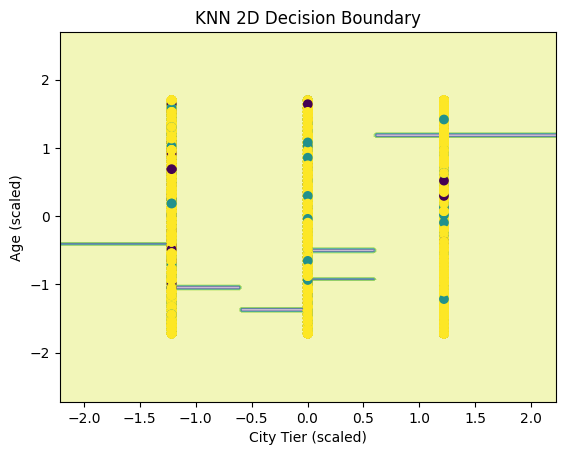

In [4]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Step 2: Load dataset
data = pd.read_csv("Consumer_Shopping_Trends_2026 (6).csv")

# Step 3: Select columns (CHANGE 'age' if needed)
data = data[['city_tier', 'age', 'shopping_preference']].dropna()

# Step 4: Encode categorical columns
le_city = LabelEncoder()
le_target = LabelEncoder()

data['city_tier'] = le_city.fit_transform(data['city_tier'])
data['shopping_preference'] = le_target.fit_transform(data['shopping_preference'])

# Step 5: Define X and y
X = data[['city_tier', 'age']].values
y = data['shopping_preference'].values

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 8: Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 9: Create meshgrid
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Step 10: Predict for grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 11: Plot decision boundary
plt.figure()

plt.contourf(xx, yy, Z, alpha=0.3)  # colored regions
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)  # data points

plt.xlabel("City Tier (scaled)")
plt.ylabel("Age (scaled)")
plt.title("KNN 2D Decision Boundary")

plt.show()